In [1]:
import numpy as np
import json
import re
import os
import string
from IPython.display import display, HTML

import tensorflow as tf
from tensorflow.keras import layers, models, losses, callbacks

# 0. Parameters

In [2]:
VOCAB_SIZE = 10000
MAX_LEN = 80
EMBEDDING_DIM = 256
KEY_DIM = 256
N_HEADS = 2
FEED_FORWARD_DIM = 256
VALIDATION_SPLIT = 0.2
SEED = 42
LOAD_MODEL = False
BATCH_SIZE = 32
EPOCHS = 5

# 1. Load the data

### Wine Data from Kaggle

### Local Data

In [3]:
import json

# Load Azerbaijani call-center dialogs from JSONL in the same folder
dialogs = []
with open("train.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        obj = json.loads(line)
        dialogs.append(obj["messages"])

def format_dialog(messages):
    """
    Turn a list of {role, content} messages into a single training string.
    Example output:
    'MÜŞTƏRİ: ... AGENT: ... MÜŞTƏRİ: ... AGENT: ...'
    """
    parts = []
    for msg in messages:
        role = msg.get("role")
        if role == "user":
            speaker = "MÜŞTƏRİ"
        elif role == "assistant":
            speaker = "AGENT"
        else:
            speaker = role.upper() if role else "SISTEM"
        parts.append(f"{speaker}: {msg['content']}")
    return " ".join(parts)

# This replaces the wine "filtered_data"
filtered_data = [format_dialog(m) for m in dialogs]

print(f"{len(filtered_data)} dialogs loaded")
print(filtered_data[0][:500])

28712 dialogs loaded
MÜŞTƏRİ: Alo, salam. AGENT: Salam. ASAN Xidmət çağrı mərkəzi, mən Nərmin. Buyurun, sizi dinləyirəm. MÜŞTƏRİ: Şəxsiyyət vəsiqəmin vaxtı bitir, yeniləmək üçün nə etməliyəm? AGENT: Əlbəttə, məlumat verim. Şəxsiyyət vəsiqəsini yeniləmək üçün sizə ən yaxın ASAN Xidmət mərkəzinə yaxınlaşmalısınız. MÜŞTƏRİ: Hansı sənədlər lazımdır? AGENT: Köhnə şəxsiyyət vəsiqəniz və dövlət rüsumunun ödənilməsi barədə qəbz tələb olunur. MÜŞTƏRİ: Rüsum nə qədərdir? AGENT: Hmm, on iş günü ərzində hazırlanması üçün dövlət


## 2. Tokenize the data

In [4]:
# Pad the punctuation, to treat them as separate 'words'
def pad_punctuation(s):
    s = re.sub(f"([{string.punctuation}, '\n'])", r" \1 ", s)
    s = re.sub(" +", " ", s)
    return s


text_data = [pad_punctuation(x) for x in filtered_data]

In [5]:
# Display an example of a recipe
example_data = text_data[25]
example_data

'MÜŞTƏRİ : Salam , nömrəmlə bağlı bir problem var . AGENT : Salam , Azercell Müştəri Xidmətlərinə xoş gəlmisiniz . Mənim adım Nərmindir . Buyurun , sizə necə kömək edə bilərəm ? MÜŞTƏRİ : İnternet paketim bitmədən sürət çox aşağı düşüb . AGENT : Başa düşdüm , narahatlığınızı anlayıram . Zəhmət olmasa , nömrənizi deyə bilərsinizmi ? MÜŞTƏRİ : Bəli , sıfır əlli , üç yüz iyirmi bir , on dörd , qırx beş . AGENT : Təşəkkür edirəm . Məlumatları yoxlayıram , xahiş edirəm xətdə qalın . MÜŞTƏRİ : Oldu , gözləyirəm . AGENT : Yoxlamaya görə , sizin “GəncOL səkkiz” paketiniz aktivdir və aylıq on beş giqabaytlıq limitin on dörd giqabaytını istifadə etmisiniz . Sürətin aşağı düşməsi bununla əlaqəli ola bilər . MÜŞTƏRİ : Axı mənə elə gəlir ki , o qədər işlətməmişəm . AGENT : Bəzən arxa planda işləyən tətbiqlər daha çox internet istifadə edə bilir . Əlavə internet paketi qoşmaq istərdinizmi ? MÜŞTƏRİ : Bəli , olar . Hansı paketlər var ? AGENT : Sizə bir , üç və beş giqabaytlıq əlavə internet paketləri

In [6]:
# Convert to a Tensorflow Dataset
text_ds = (
    tf.data.Dataset.from_tensor_slices(text_data)
    .batch(BATCH_SIZE)
    .shuffle(1000)
)

In [7]:
# Create a vectorisation layer
vectorize_layer = layers.TextVectorization(
    standardize="lower",
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN + 1,
)

In [8]:
# Adapt the layer to the training set
vectorize_layer.adapt(text_ds)
vocab = vectorize_layer.get_vocabulary()

In [ ]:
with open("vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False)

In [9]:
# Display some token:word mappings
for i, word in enumerate(vocab[:10]):
    print(f"{i}: {word}")

0: 
1: [UNK]
2: .
3: :
4: ,
5: agent
6: mÜŞtƏrİ
7: ?
8: və
9: bir


In [10]:
# Display the same example converted to ints
example_tokenised = vectorize_layer(example_data)
print(example_tokenised.numpy())

[   6    3   11    4 7345   76    9  131   24    2    5    3   11    4
  323  146  694   85  120    2  155   22 1544    2   21    4   25   35
   63   23   30    7    6    3  842 3715 7043 1486   96 1004 4192    2
    5    3  150  202    4 2292  290    2   37   34    4  136   91  216
    7    6    3   14    4   69   94    4   42   26   54    9    4   16
   52    4  169   19    2    5    3   47   36    2  210]


## 3. Create the Training Set

In [11]:
# Create the training set of recipes and the same text shifted by one word
def prepare_inputs(text):
    text = tf.expand_dims(text, -1)
    tokenized_sentences = vectorize_layer(text)
    x = tokenized_sentences[:, :-1]
    y = tokenized_sentences[:, 1:]
    return x, y


train_ds = text_ds.map(prepare_inputs)

In [12]:
example_input_output = train_ds.take(1).get_single_element()

In [13]:
# Example Input
example_input_output[0][0]

<tf.Tensor: shape=(80,), dtype=int64, numpy=
array([   6,    3,  573,    2, 3960, 4674,    1,    1,  443,    1, 8862,
          7,    5,    3,  583,  603,    2, 2128, 5599,  369,    2, 1438,
        834, 8373,    2, 1150, 1757, 4674,    1,    4,    1,  443,    1,
       3314,    1,    1, 5300, 3065,    1,  517,    1,    1,    1,    2,
          6,    3, 1414, 2940, 3826, 4047,    7,    5,    3,  944,    4,
       3779,    2, 2100, 3958,    1, 8683,  369, 3360,    1, 9710, 1735,
          1,    4,    1,  517,    1,    1,  443,    1,    1,    2,    0,
          0,    0,    0])>

In [14]:
# Example Output (shifted by one token)
example_input_output[1][0]

<tf.Tensor: shape=(80,), dtype=int64, numpy=
array([   3,  573,    2, 3960, 4674,    1,    1,  443,    1, 8862,    7,
          5,    3,  583,  603,    2, 2128, 5599,  369,    2, 1438,  834,
       8373,    2, 1150, 1757, 4674,    1,    4,    1,  443,    1, 3314,
          1,    1, 5300, 3065,    1,  517,    1,    1,    1,    2,    6,
          3, 1414, 2940, 3826, 4047,    7,    5,    3,  944,    4, 3779,
          2, 2100, 3958,    1, 8683,  369, 3360,    1, 9710, 1735,    1,
          4,    1,  517,    1,    1,  443,    1,    1,    2,    0,    0,
          0,    0,    0])>

## 4. Create the causal attention mask function

In [15]:
def causal_attention_mask(batch_size, n_dest, n_src, dtype):
    i = tf.range(n_dest)[:, None]
    j = tf.range(n_src)
    m = i >= j - n_src + n_dest
    mask = tf.cast(m, dtype)
    mask = tf.reshape(mask, [1, n_dest, n_src])
    mult = tf.concat(
        [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)], 0
    )
    return tf.tile(mask, mult)


np.transpose(causal_attention_mask(1, 10, 10, dtype=tf.int32)[0])

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], dtype=int32)

## 5. Create a Transformer Block layer

In [16]:
class TransformerBlock(layers.Layer):
    def __init__(self, num_heads, key_dim, embed_dim, ff_dim, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.attn = layers.MultiHeadAttention(
            num_heads, key_dim, output_shape=embed_dim
        )
        self.dropout_1 = layers.Dropout(self.dropout_rate)
        self.ln_1 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn_1 = layers.Dense(self.ff_dim, activation="relu")
        self.ffn_2 = layers.Dense(self.embed_dim)
        self.dropout_2 = layers.Dropout(self.dropout_rate)
        self.ln_2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        causal_mask = causal_attention_mask(
            batch_size, seq_len, seq_len, tf.bool
        )
        attention_output, attention_scores = self.attn(
            inputs,
            inputs,
            attention_mask=causal_mask,
            return_attention_scores=True,
        )
        attention_output = self.dropout_1(attention_output)
        out1 = self.ln_1(inputs + attention_output)
        ffn_1 = self.ffn_1(out1)
        ffn_2 = self.ffn_2(ffn_1)
        ffn_output = self.dropout_2(ffn_2)
        return (self.ln_2(out1 + ffn_output), attention_scores)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "key_dim": self.key_dim,
                "embed_dim": self.embed_dim,
                "num_heads": self.num_heads,
                "ff_dim": self.ff_dim,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

## 6. Create the Token and Position Embedding

In [17]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "max_len": self.max_len,
                "vocab_size": self.vocab_size,
                "embed_dim": self.embed_dim,
            }
        )
        return config

## 7. Build the Transformer model

In [18]:
inputs = layers.Input(shape=(None,), dtype=tf.int32)
x = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBEDDING_DIM)(inputs)
x, attention_scores = TransformerBlock(
    N_HEADS, KEY_DIM, EMBEDDING_DIM, FEED_FORWARD_DIM
)(x)
outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(x)
gpt = models.Model(inputs=inputs, outputs=[outputs, attention_scores])
gpt.compile("adam", loss=[losses.SparseCategoricalCrossentropy(), None])

In [19]:
gpt.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ token_and_position_embedding         │ (None, None, 256)           │       2,580,480 │
│ (TokenAndPositionEmbedding)          │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block (TransformerBlock) │ [(None, None, 256), (None,  │         658,688 │
│                                      │ 2, None, None)]             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, None, 10000)         │       2,570,000 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,809,168 (22.16 MB)

 Trainable params: 5,809,168 (22.16 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
if LOAD_MODEL:
    # model.load_weights('./models/model')
    gpt = models.load_model("./models/gpt", compile=True)

## 8. Train the Transformer

In [21]:
# Create a TextGenerator checkpoint
class TextGenerator(callbacks.Callback):
    def __init__(self, index_to_word, top_k=10):
        self.index_to_word = index_to_word
        self.word_to_index = {
            word: index for index, word in enumerate(index_to_word)
        }

    def sample_from(self, probs, temperature):
        probs = probs ** (1 / temperature)
        probs = probs / np.sum(probs)
        return np.random.choice(len(probs), p=probs), probs

    def generate(self, start_prompt, max_tokens, temperature):
        start_tokens = [
            self.word_to_index.get(x, 1) for x in start_prompt.split()
        ]
        sample_token = None
        info = []
        while len(start_tokens) < max_tokens and sample_token != 0:
            x = np.array([start_tokens])
            y, att = self.model.predict(x, verbose=0)
            sample_token, probs = self.sample_from(y[0][-1], temperature)
            info.append(
                {
                    "prompt": start_prompt,
                    "word_probs": probs,
                    "atts": att[0, :, -1, :],
                }
            )
            start_tokens.append(sample_token)
            start_prompt = start_prompt + " " + self.index_to_word[sample_token]
        print(f"\ngenerated text:\n{start_prompt}\n")
        return info

    def on_epoch_end(self, epoch, logs=None):
        self.generate("müştəri: salam internetim işləmir agent:", max_tokens=80, temperature=1.0)

In [22]:
# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint/checkpoint.weights.h5",
    save_weights_only=True,
    save_freq="epoch",
    verbose=0,
)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")

# Tokenize starting prompt
text_generator = TextGenerator(vocab)

In [23]:
history = gpt.fit(
    train_ds,
    epochs=EPOCHS,
    callbacks=[model_checkpoint_callback, tensorboard_callback, text_generator],
)

Epoch 1/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 3.2997
generated text:
müştəri: salam internetim işləmir agent: müraciət nömrənizi və [UNK] 

898/898 ━━━━━━━━━━━━━━━━━━━━ 87s 95ms/step - loss: 2.3683
Epoch 2/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 1.5252
generated text:
müştəri: salam internetim işləmir agent: . mÜŞtƏrİ : bu . agent : salam , port baku [UNK] [UNK] [UNK] , mən данные . zəhmət olmasa , siqnal ? agent : [UNK] служба [UNK] . [UNK] təəssüf ki , lakin bəzi gönderilecektir . onlar sizə avtomobilinizin markası və modeli , istehsal ilindən və istehsal tarixi xahiş edirik . mÜŞtƏrİ : nömrəm [UNK] qəribə [UNK] [UNK] nələri əhatə edir . agent : anladım . alış zamanı bütün mağazalar [UNK] əsasən , [UNK]

898/898 ━━━━━━━━━━━━━━━━━━━━ 91s 101ms/step - loss: 1.4887
Epoch 3/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1.2769
generated text:
müştəri: salam internetim işləmir agent: məlumat [UNK] , [UNK] . mÜŞtƏrİ : hər il . agent : aydındır . zəhmət olmasa

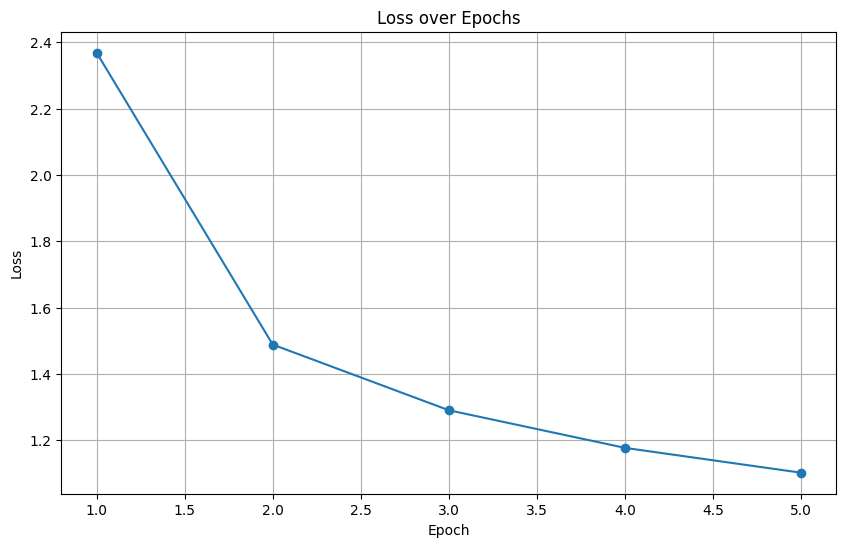

In [24]:
import matplotlib.pyplot as plt

# Extract the loss values
loss = history.history['loss']

# Plot the loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss)+1), loss, marker='o')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [25]:
# Create the 'models' directory if it doesn't exist
os.makedirs("./models", exist_ok=True)

# Save the final model
gpt.save("./models/gpt.keras")

## 9. Generate text using the Transformer

In [26]:
def print_probs(info, vocab, top_k=5):
    for i in info:
        highlighted_text = []
        for word, att_score in zip(
            i["prompt"].split(), np.mean(i["atts"], axis=0)
        ):
            highlighted_text.append(
                '<span style="background-color:rgba(135,206,250,'
                + str(att_score / max(np.mean(i["atts"], axis=0)))
                + ');">'
                + word
                + "</span>"
            )
        highlighted_text = " ".join(highlighted_text)
        display(HTML(highlighted_text))

        word_probs = i["word_probs"]
        p_sorted = np.sort(word_probs)[::-1][:top_k]
        i_sorted = np.argsort(word_probs)[::-1][:top_k]
        for p, i in zip(p_sorted, i_sorted):
            print(f"{vocab[i]}:   \t{np.round(100*p,2)}%")
        print("--------\n")

In [27]:
info = text_generator.generate(
    "müştəri salam internetim işləmir agent", max_tokens=80, temperature=1.0
)


generated text:
müştəri salam internetim işləmir agent : salam . müştəri xidmətlərinə xoş xoş gəlmisiniz . adım səbinədir . sizə necə kömək edə bilərəm ? mÜŞtƏrİ : mən internet paketini tövsiyə edirəm . bir neçə klass tarifini seçə bilərəm . saytda edə bilərəm . daha çox internet və internet paketləri var . məsələn , gündəlik paketimiz var . mÜŞtƏrİ : daha çox danışıq . agent : o zaman on günlük internet , aylıq danışıq dəqiqələri internet paketi var . məsələn , '



In [28]:
info = text_generator.generate(
    "müştəri salam balansım düz gəlmir agent", max_tokens=80, temperature=0.5
)


generated text:
müştəri salam balansım düz gəlmir agent : salam , bir - doqquz - bir - doqquz - doqquz . adım [UNK] . buyurun . mÜŞtƏrİ : salam . mən [UNK] [UNK] bağlı sizə necə kömək edə bilərəm ? agent : salam . [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] , [UNK] və [UNK] . mÜŞtƏrİ : Çox yaxşı . agent : anlayıram . bu çox təəssüf ki , biz operator çox [UNK] . bu vəziyyət [UNK] . bu



In [29]:
info = text_generator.generate(
    "müştəri salam wifi-yə qoşula bilmirəm agent", max_tokens=80, temperature=0.5
)


generated text:
müştəri salam wifi-yə qoşula bilmirəm agent : dəstək xidməti . adım elvin . buyurun . mÜŞtƏrİ : salam . mÜŞtƏrİ : mən nömrəmi öz adıma keçirmək istəyirəm . agent : anladım . bu əməliyyat " ad dəyişimi " adlanır . bunun üçün həm nömrənin hazırkı sahibi , həm də siz şəxsiyyət vəsiqələrinizlə birlikdə istənilən azercell ekspres ofisinə yaxınlaşmalısınız . mÜŞtƏrİ : bəs nömrənin sahibi xaricdədir , gələ bilmir . agent : bu halda nömrənin sahibi xaricdəki azərbaycan səfirliyi və ya



::   	100.0%
.:   	0.0%
[UNK]:   	0.0%
bir:   	0.0%
-:   	0.0%
--------



dəstək:   	49.310001373291016%
salam:   	26.84000015258789%
xoş:   	23.270000457763672%
[UNK]:   	0.3700000047683716%
məlumat:   	0.03999999910593033%
--------



xidməti:   	75.8499984741211%
xidmətinə:   	23.6299991607666%
xətti:   	0.1899999976158142%
dəstək:   	0.14000000059604645%
xəttinə:   	0.10000000149011612%
--------



,:   	94.98999786376953%
.:   	4.869999885559082%
[UNK]:   	0.07000000029802322%
ilə:   	0.03999999910593033%
çağrı:   	0.009999999776482582%
--------



...

xaricdəki:   	99.8499984741211%
sizə:   	0.09000000357627869%
sizin:   	0.029999999329447746%
şəxsiyyət:   	0.009999999776482582%
ölkə:   	0.009999999776482582%
--------



azərbaycan:   	100.0%
[UNK]:   	0.0%
kontakt:   	0.0%
wolt:   	0.0%
bu:   	0.0%
--------



səfirliyi:   	75.4800033569336%
səfirliyindən:   	23.829999923706055%
səfirliyinə:   	0.6899999976158142%
[UNK]:   	0.0%
etibarnamə:   	0.0%
--------



və:   	100.0%
,:   	0.0%
[UNK]:   	0.0%
(:   	0.0%
yolu:   	0.0%
--------



ya:   	100.0%
adınıza:   	0.0%
':   	0.0%
digər:   	0.0%
siz:   	0.0%
--------



In [ ]:
print_probs(info, vocab)

## Inference

In [ ]:
import json

with open("vocab.json", "r", encoding="utf-8") as f:
    vocab = json.load(f)

In [2]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# make sure this exists too
def causal_attention_mask(batch_size, n_dest, n_src, dtype):
    i = tf.range(n_dest)[:, None]
    j = tf.range(n_src)
    m = i >= j - n_src + n_dest
    mask = tf.cast(m, dtype)
    mask = tf.reshape(mask, [1, n_dest, n_src])
    mult = tf.concat(
        [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)],
        0,
    )
    return tf.tile(mask, mult)

class TransformerBlock(layers.Layer):
    def __init__(
        self,
        num_heads,
        key_dim,
        embed_dim,
        ff_dim,
        dropout_rate=0.1,
        **kwargs,          # <-- accept extra args (name, dtype, etc.)
    ):
        super().__init__(**kwargs)   # <-- pass them to base class
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate

        self.attn = layers.MultiHeadAttention(
            num_heads, key_dim, output_shape=embed_dim
        )
        self.dropout_1 = layers.Dropout(self.dropout_rate)
        self.ln_1 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn_1 = layers.Dense(self.ff_dim, activation="relu")
        self.ffn_2 = layers.Dense(self.embed_dim)
        self.dropout_2 = layers.Dropout(self.dropout_rate)
        self.ln_2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        causal_mask = causal_attention_mask(
            batch_size, seq_len, seq_len, tf.bool
        )
        attention_output, attention_scores = self.attn(
            inputs,
            inputs,
            attention_mask=causal_mask,
            return_attention_scores=True,
        )
        attention_output = self.dropout_1(attention_output)
        out1 = self.ln_1(inputs + attention_output)
        ffn_1 = self.ffn_1(out1)
        ffn_2 = self.ffn_2(ffn_1)
        ffn_output = self.dropout_2(ffn_2)
        return (self.ln_2(out1 + ffn_output), attention_scores)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "key_dim": self.key_dim,
                "embed_dim": self.embed_dim,
                "num_heads": self.num_heads,
                "ff_dim": self.ff_dim,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config


class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)        # <-- here too
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "max_len": self.max_len,
                "vocab_size": self.vocab_size,
                "embed_dim": self.embed_dim,
            }
        )
        return config


In [3]:
gpt = keras.models.load_model(
    "./models/gpt.keras",
    custom_objects={
        "TokenAndPositionEmbedding": TokenAndPositionEmbedding,
        "TransformerBlock": TransformerBlock,
    }
)

C:\Proxima Tech Solutions\Proxima AI Voice Call Center\DS-SLM\gpt\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'token_and_position_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
C:\Proxima Tech Solutions\Proxima AI Voice Call Center\DS-SLM\gpt\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
index_to_word = vocab
word_to_index = {w: i for i, w in enumerate(vocab)}

In [ ]:
import numpy as np
import tensorflow as tf

class TextGenerator:
    def __init__(self, model, index_to_word, word_to_index, oov_index=1):
        self.model = model
        self.index_to_word = index_to_word
        self.word_to_index = word_to_index
        self.oov_index = oov_index  # usually 1 for TextVectorization

    def sample_from(self, probs, temperature):
        probs = np.asarray(probs, dtype="float64")
        probs = probs ** (1.0 / temperature)
        probs = probs / np.sum(probs)
        return np.random.choice(len(probs), p=probs)

    def encode(self, text):
        # mirror your training preprocessing as closely as possible
        text = text.lower()
        tokens = text.split()
        return [self.word_to_index.get(t, self.oov_index) for t in tokens]

    def decode(self, token_ids):
        return " ".join(self.index_to_word[i] for i in token_ids)

    def generate(self, prompt, max_tokens=80, temperature=0.7):
        token_ids = self.encode(prompt)
        sample_token = None

        while len(token_ids) < max_tokens and sample_token != 0:
            x = np.array([token_ids], dtype="int32")
            # model outputs: [logits, attention_scores]
            y, _ = self.model.predict(x, verbose=0)
            next_probs = y[0, -1]  # last position
            sample_token = self.sample_from(next_probs, temperature)
            token_ids.append(sample_token)

        return self.decode(token_ids)

In [ ]:
tg = TextGenerator(
    model=gpt,
    index_to_word=index_to_word,
    word_to_index=word_to_index,
)

prompt = "müştəri salam wifi-yə qoşula bilmirəm agent"
text = tg.generate(prompt, max_tokens=80, temperature=0.6)
print(text)